# 3. Tuning, sampling, ensembles, calibration and the frozen test evaluation

Order of operations, and the reason for it:

1. hyperparameters are searched on the training partition only;
2. the sampling method is chosen on validation, with hyperparameters already fixed;
3. candidate ensembles are defined before any validation outcome is read, then
   one is chosen on validation;
4. the calibrator is fitted on training out-of-fold probabilities, so
   calibration never consumes validation outcomes;
5. the decision threshold is selected on validation;
6. the frozen configuration is evaluated on the test partition.

Validation is spent on the development decisions the protocol prescribes:
sampler, ensemble and threshold. Test outcomes enter none of them. Test
probabilities are computed alongside validation probabilities for convenience,
but no test outcome is used for model development or configuration selection,
and everything downstream reads the stored predictions.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
from sklearn.base import clone

import config
import ensemble as ens
import train
import utils

utils.ensure_dirs()
utils.set_seed()
print("profile:", config.PROFILE)
print("search draws:", config.SEARCH_ITER, "| inner cv:", config.INNER_CV,
      "| bootstrap:", config.BOOTSTRAP)
print("primary contrast:", config.PRIMARY_BASELINE, "vs", config.PRIMARY_THYROID)
print("calibration:", config.CALIBRATION_PRIMARY,
      "| sensitivity:", config.CALIBRATION_SENSITIVITY)

profile: full
search draws: 1000 | inner cv: 2 | bootstrap: 2000
primary contrast: CV17 vs CV17_THY_CONT
calibration: sigmoid | sensitivity: isotonic


In [2]:
def load_partition(horizon, feature_set):
    strict = utils.read_frame(str(config.COHORT_STRICT).format(horizon=horizon))
    splits = utils.load_splits(horizon)
    utils.assert_disjoint(splits)
    X, y, ids = utils.extract_xy(strict, feature_set)
    masks = utils.split_masks(ids, splits)
    return {"X": X, "y": y, "ids": ids, "masks": masks,
            "fingerprint": utils.data_fingerprint(strict, list(X.columns))}


def part(data, name):
    mask = data["masks"][name]
    return data["X"][mask], data["y"][mask], data["ids"][mask]

## 3.1 Hyperparameter search on the training partition

Cached by a signature that covers the data fingerprint, the feature list, the
search budget and the dependency versions. The search-space version is recorded
per model, so revising one model's space leaves every other cached job usable.
Loading a cache never triggers a fit.

The scorer is macro-F1, which calls `predict`, so the search runs without
probability estimates and the winning configuration is refitted with them. Only
that final in-process fit can report convergence warnings: candidate-level
warnings are raised inside the parallel workers and are not observable from
here. Candidates that fail outright are counted separately.

In [3]:
def tune_model(horizon, feature_set, model_name, sampler):
    data = load_partition(horizon, feature_set)
    X_train, y_train, _ = part(data, "train")
    name = f"tuned_h{horizon}_{feature_set}_{model_name}"
    signature = utils.cache_signature(
        stage="tune", horizon=horizon, feature_set=feature_set,
        features=list(data["X"].columns), model=model_name, sampler=sampler,
        n_iter=config.SEARCH_ITER, inner_cv=config.INNER_CV,
        search_space=train.search_space_version(model_name),
        fingerprint=data["fingerprint"])

    manifest_path = config.MODELS_DIR / f"{name}_manifest.json"
    if config.USE_CACHE and manifest_path.exists():
        # A run interrupted mid-write can leave a truncated manifest or model.
        # Treat anything unreadable as a cache miss rather than crashing.
        try:
            stored = json.loads(manifest_path.read_text(encoding="utf-8"))
            if stored.get("signature") == signature:
                return train.load_model(name), stored
        except (json.JSONDecodeError, OSError, EOFError, KeyError) as error:
            print(f"  discarding unreadable cache for {name}: {type(error).__name__}")

    result = train.tune(X_train, y_train, model_name, sampler, feature_set)
    estimator = result.pop("estimator")
    train.save_model(estimator, name, signature=signature, horizon=horizon, **result)
    return estimator, {**result, "signature": signature, "horizon": horizon}


search_rows = []
tuned = {}
for horizon in config.HORIZONS:
    for feature_set in config.TUNING_FEATURE_SETS:
        for model_name in config.MODELS:
            estimator, info = tune_model(horizon, feature_set, model_name,
                                         config.DEV_SAMPLER)
            tuned[(horizon, feature_set, model_name)] = estimator
            search_rows.append({k: v for k, v in info.items()
                                if k not in ("dependencies", "best_params")}
                               | {"best_params": json.dumps(info.get("best_params", {}))})

search_results = pd.DataFrame(search_rows)
utils.save_result(search_results, "hyperparameter_search")
search_results[["horizon", "feature_set", "model", "best_cv_f1_macro",
                "n_candidates", "n_failed_candidates",
                "final_fit_convergence_warnings",
                "elapsed_seconds"]].round(4)

,horizon,feature_set,model,best_cv_f1_macro,n_candidates,n_failed_candidates,final_fit_convergence_warnings,elapsed_seconds
0,7,CV17,LogisticRegression,0.7027,1000,0,0,19.13
1,7,CV17,SVC,0.7196,1000,0,0,363.34
2,7,CV17,KNeighbors,0.6861,1000,0,0,54.55
3,7,CV17,RandomForest,0.7171,1000,0,0,688.85
4,7,CV17,AdaBoost,0.7113,1000,0,0,478.01
...,...,...,...,...,...,...,...,...
75,10,CV17_THY_CONT_RATIO,RandomForest,0.7806,1000,0,0,445.03
76,10,CV17_THY_CONT_RATIO,AdaBoost,0.7796,1000,0,0,348.84
77,10,CV17_THY_CONT_RATIO,MLP,0.7808,1000,0,0,73.63
78,10,CV17_THY_CONT_RATIO,GradientBoosting,0.7781,1000,0,0,353.50


## 3.2 Candidate ensembles

The candidate set is fixed here, before any validation outcome is read: the
prespecified paper ensemble, the three best models by training-only
cross-validation, and one diverse combination declared in `config.py`. Only
these models need out-of-fold probabilities, so the expensive stages below are
restricted to them.

In [4]:
train_rank = utils.read_frame(config.RESULTS_DIR / "training_cv_model_rank.csv")

candidate_rows = []
candidates_by_horizon = {}
for horizon in config.HORIZONS:
    rank = train_rank[train_rank["horizon"] == horizon]
    candidates = ens.candidate_ensembles(rank)
    candidates_by_horizon[horizon] = candidates
    for name, members in candidates.items():
        candidate_rows.append({"horizon": horizon, "candidate": name,
                               "members": ",".join(members)})

candidate_table = pd.DataFrame(candidate_rows)
utils.save_result(candidate_table, "ensemble_candidates")

ensemble_models = sorted({m for candidates in candidates_by_horizon.values()
                          for members in candidates.values() for m in members})
print("models entering at least one candidate ensemble:", ensemble_models)
candidate_table

models entering at least one candidate ensemble: ['AdaBoost', 'GradientBoosting', 'LogisticRegression', 'MLP', 'RandomForest', 'SVC', 'XGBoost']


,horizon,candidate,members
0,7,paper,"LogisticRegression,RandomForest,AdaBoost"
1,7,top3_train_cv,"GradientBoosting,LogisticRegression,AdaBoost"
2,7,diverse,"LogisticRegression,XGBoost,MLP"
3,10,paper,"LogisticRegression,RandomForest,AdaBoost"
4,10,top3_train_cv,"RandomForest,LogisticRegression,SVC"
5,10,diverse,"LogisticRegression,XGBoost,MLP"


## 3.3 Sampling comparison

Hyperparameters are already fixed, so only the sampler changes. Selection uses
validation, never test. Plain SMOTE variants interpolate binary dummies into
fractional values and are therefore reported as a paper-replication sensitivity
rather than treated as preferred.

In [5]:
def sampler_candidates():
    candidates = list(config.SAMPLERS)
    if config.RUN_PAPER_REPLICATION_SAMPLERS:
        candidates += list(config.SAMPLERS_PAPER_REPLICATION)
    return candidates


def compare_samplers(horizon, feature_set, model_name):
    data = load_partition(horizon, feature_set)
    X_train, y_train, _ = part(data, "train")
    X_valid, y_valid, _ = part(data, "valid")
    best_params = train.model_manifest(
        f"tuned_h{horizon}_{feature_set}_{model_name}")["best_params"]

    rows = []
    for sampler in sampler_candidates():
        if sampler == "class_weight" and not train.supports_class_weight(model_name):
            continue
        pipe = train.make_pipeline(model_name, sampler, feature_set)
        pipe.set_params(**best_params)
        try:
            pipe.fit(X_train, y_train)
            proba = pipe.predict_proba(X_valid)[:, 1]
        except Exception as error:
            rows.append({"horizon": horizon, "feature_set": feature_set,
                         "model": model_name, "sampler": sampler,
                         "status": f"failed: {type(error).__name__}"})
            continue
        rows.append({
            "horizon": horizon, "feature_set": feature_set, "model": model_name,
            "sampler": sampler, "status": "ok",
            "replication_only": sampler in config.SAMPLERS_PAPER_REPLICATION,
            **utils.classification_metrics(y_valid, proba, 0.5),
        })
    return pd.DataFrame(rows)


if config.RUN_SAMPLING_COMPARISON:
    signature = utils.cache_signature(
        stage="sampling", horizons=list(config.HORIZONS),
        feature_sets=list(config.TUNING_FEATURE_SETS), models=ensemble_models,
        candidates=sampler_candidates(), n_iter=config.SEARCH_ITER)
    sampling_results = utils.load_cache("sampling", signature)
    if sampling_results is None:
        sampling_results = pd.concat(
            [compare_samplers(h, fs, m) for h in config.HORIZONS
             for fs in config.TUNING_FEATURE_SETS for m in ensemble_models],
            ignore_index=True)
        utils.save_cache(sampling_results, "sampling", signature)
    utils.save_result(sampling_results, "sampling_comparison")
    display(sampling_results[sampling_results["status"] == "ok"]
            .sort_values(["horizon", "feature_set", "model", "f1_macro"],
                         ascending=[True, True, True, False])
            [["horizon", "feature_set", "model", "sampler", "replication_only",
              "f1_macro", "roc_auc", "auprc", "brier"]].round(4))
else:
    sampling_results = pd.DataFrame()

,horizon,feature_set,model,sampler,replication_only,f1_macro,roc_auc,auprc,brier
5,7,CV17,AdaBoost,SVMSMOTE,True,0.7240,0.8420,0.6032,0.1867
3,7,CV17,AdaBoost,SMOTE,True,0.7182,0.8357,0.5726,0.1962
2,7,CV17,AdaBoost,SMOTENC,False,0.7129,0.8361,0.5944,0.1953
1,7,CV17,AdaBoost,RandomOverSampler,False,0.7128,0.8487,0.6300,0.1917
4,7,CV17,AdaBoost,BorderlineSMOTE,True,0.7126,0.8374,0.5731,0.1932
...,...,...,...,...,...,...,...,...,...
359,10,CV17_THY_STATES,XGBoost,SVMSMOTE,True,0.7325,0.8094,0.7367,0.1772
357,10,CV17_THY_STATES,XGBoost,SMOTE,True,0.7296,0.8100,0.7391,0.1769
355,10,CV17_THY_STATES,XGBoost,RandomOverSampler,False,0.7284,0.8103,0.7388,0.1766
356,10,CV17_THY_STATES,XGBoost,SMOTENC,False,0.7257,0.8048,0.7376,0.1771


In [6]:
def chosen_sampler(horizon, feature_set, model_name):
    """Best validation sampler among the methods that respect binary dummies."""
    if sampling_results.empty:
        return config.DEV_SAMPLER
    subset = sampling_results[
        (sampling_results["horizon"] == horizon)
        & (sampling_results["feature_set"] == feature_set)
        & (sampling_results["model"] == model_name)
        & (sampling_results["status"] == "ok")
        & (~sampling_results["replication_only"].fillna(False))]
    if subset.empty:
        return config.DEV_SAMPLER
    ranked = subset.sort_values(["f1_macro", "roc_auc", "sampler"],
                                ascending=[False, False, True])
    return str(ranked.iloc[0]["sampler"])


sampler_choice = pd.DataFrame([
    {"horizon": h, "feature_set": fs, "model": m,
     "sampler": chosen_sampler(h, fs, m)}
    for h in config.HORIZONS for fs in config.TUNING_FEATURE_SETS
    for m in ensemble_models])
utils.save_result(sampler_choice, "sampler_choice")
sampler_choice.pivot_table(index=["horizon", "model"], columns="feature_set",
                           values="sampler", aggfunc="first")

feature_set                              CV17      CV17_THY_CONT  \
horizon model                                                      
7       AdaBoost                      SMOTENC  RandomOverSampler   
        GradientBoosting              SMOTENC  RandomOverSampler   
        LogisticRegression  RandomOverSampler  RandomOverSampler   
        MLP                 RandomOverSampler  RandomOverSampler   
        RandomForest             class_weight  RandomOverSampler   
        SVC                           SMOTENC       class_weight   
        XGBoost             RandomOverSampler  RandomOverSampler   
10      AdaBoost            RandomOverSampler            SMOTENC   
        GradientBoosting              SMOTENC            SMOTENC   
        LogisticRegression            SMOTENC       class_weight   
        MLP                           SMOTENC               none   
        RandomForest             class_weight       class_weight   
        SVC                      class_weight       class_weight   
        XGBoost             RandomOverSampler  RandomOverSampler   

feature_set                CV17_THY_CONT_RATIO CV17_THY_CONT_STATES  \
horizon model                                                         
7       AdaBoost             RandomOverSampler    RandomOverSampler   
        GradientBoosting                  none    RandomOverSampler   
        LogisticRegression   RandomOverSampler              SMOTENC   
        MLP                               none    RandomOverSampler   
        RandomForest              class_weight    RandomOverSampler   
        SVC                       class_weight         class_weight   
        XGBoost              RandomOverSampler              SMOTENC   
10      AdaBoost             RandomOverSampler    RandomOverSampler   
        GradientBoosting               SMOTENC    RandomOverSampler   
        LogisticRegression        class_weight    RandomOverSampler   
        MLP                               none    RandomOverSampler   
        RandomForest              class_weight    RandomOverSampler   
        SVC                       class_weight         class_weight   
        XGBoost              RandomOverSampler    RandomOverSampler   

feature_set                   CV17_THY_STATES  
horizon model                                  
7       AdaBoost            RandomOverSampler  
        GradientBoosting                 none  
        LogisticRegression       class_weight  
        MLP                 RandomOverSampler  
        RandomForest        RandomOverSampler  
        SVC                 RandomOverSampler  
        XGBoost                       SMOTENC  
10      AdaBoost                         none  
        GradientBoosting              SMOTENC  
        LogisticRegression       class_weight  
        MLP                 RandomOverSampler  
        RandomForest                     none  
        SVC                      class_weight  
        XGBoost             RandomOverSampler

## 3.4 Member probabilities

For every model: training out-of-fold probabilities, which the calibrator will
use, plus validation and test probabilities from a fit on the training
partition. The test probabilities are computed here but are not inspected until
the configuration is frozen.

In [7]:
def member_probabilities(horizon, feature_set, model_name, params=None,
                          sampler=None):
    data = load_partition(horizon, feature_set)
    X_train, y_train, ids_train = part(data, "train")
    sampler = sampler or chosen_sampler(horizon, feature_set, model_name)
    if params is None:
        params = train.model_manifest(
            f"tuned_h{horizon}_{feature_set}_{model_name}")["best_params"]

    pipe = train.make_pipeline(model_name, sampler, feature_set)
    pipe.set_params(**params)

    oof = train.training_oof_proba(clone(pipe), X_train, y_train)
    pipe.fit(X_train, y_train)
    out = {"train_oof": oof, "y_train": y_train, "ids_train": ids_train,
           "sampler": sampler, "params": params}
    for split in ("valid", "test"):
        X_split, y_split, ids_split = part(data, split)
        out[f"proba_{split}"] = pipe.predict_proba(X_split)[:, 1]
        out[f"y_{split}"] = y_split
        out[f"ids_{split}"] = ids_split
    out["estimator"] = pipe
    return out


probabilities = {}
for horizon in config.HORIZONS:
    for feature_set in config.TUNING_FEATURE_SETS:
        for model_name in ensemble_models:
            probabilities[(horizon, feature_set, model_name)] = member_probabilities(
                horizon, feature_set, model_name)
print(f"member probability sets computed: {len(probabilities)}")

member probability sets computed: 70


## 3.5 Ensembles

The paper ensemble is prespecified and is always reported. The adapted ensemble
is chosen on validation from a candidate set whose membership was fixed
beforehand, using the training-only ranking from notebook 2. Candidates are
compared at a fixed 0.5 threshold, so the choice reflects the members rather
than a second threshold search.

In [8]:
def ensemble_validation(horizon, feature_set):
    candidates = candidates_by_horizon[horizon]
    probas = {m: probabilities[(horizon, feature_set, m)]["proba_valid"]
              for m in ensemble_models}
    ids = {m: probabilities[(horizon, feature_set, m)]["ids_valid"]
           for m in ensemble_models}
    ens.check_members_aligned(ids)
    y_valid = probabilities[(horizon, feature_set, ensemble_models[0])]["y_valid"]
    scores = ens.evaluate_candidates(candidates, probas, y_valid, 0.5)
    scores.insert(0, "feature_set", feature_set)
    scores.insert(0, "horizon", horizon)
    return scores


ensemble_scores = pd.concat(
    [ensemble_validation(h, fs) for h in config.HORIZONS
     for fs in config.TUNING_FEATURE_SETS], ignore_index=True)
utils.save_result(ensemble_scores, "ensemble_validation")
ensemble_scores[["horizon", "feature_set", "candidate", "members",
                 "f1_macro", "roc_auc", "auprc", "brier"]].round(4)

,horizon,feature_set,candidate,members,f1_macro,roc_auc,auprc,brier
0,7,CV17,paper,"LogisticRegression,RandomForest,AdaBoost",0.7135,0.8417,0.6086,0.1583
1,7,CV17,top3_train_cv,"GradientBoosting,LogisticRegression,AdaBoost",0.7066,0.8414,0.6064,0.1582
2,7,CV17,diverse,"LogisticRegression,XGBoost,MLP",0.6969,0.8399,0.6072,0.1604
3,7,CV17_THY_CONT,paper,"LogisticRegression,RandomForest,AdaBoost",0.7244,0.8388,0.6256,0.1492
4,7,CV17_THY_CONT,top3_train_cv,"GradientBoosting,LogisticRegression,AdaBoost",0.7204,0.8389,0.6167,0.1535
5,7,CV17_THY_CONT,diverse,"LogisticRegression,XGBoost,MLP",0.7129,0.8370,0.6136,0.1525
6,7,CV17_THY_STATES,paper,"LogisticRegression,RandomForest,AdaBoost",0.7020,0.8384,0.6166,0.1620
7,7,CV17_THY_STATES,top3_train_cv,"GradientBoosting,LogisticRegression,AdaBoost",0.7338,0.8444,0.6303,0.1408
8,7,CV17_THY_STATES,diverse,"LogisticRegression,XGBoost,MLP",0.6923,0.8235,0.5950,0.1712
9,7,CV17_THY_CONT_STATES,paper,"LogisticRegression,RandomForest,AdaBoost",0.7250,0.8376,0.6231,0.1531


In [9]:
# The adapted ensemble is selected on the primary baseline only, so that the
# baseline-versus-thyroid contrast reflects the features and not a change of
# model family.
adapted = {}
for horizon in config.HORIZONS:
    subset = ensemble_scores[(ensemble_scores["horizon"] == horizon)
                             & (ensemble_scores["feature_set"] == config.PRIMARY_BASELINE)]
    adapted[horizon] = ens.select_ensemble(subset)
    print(f"horizon {horizon}: adapted ensemble = {adapted[horizon]} "
          f"(paper ensemble is always reported as well)")

horizon 7: adapted ensemble = paper (paper ensemble is always reported as well)
horizon 10: adapted ensemble = diverse (paper ensemble is always reported as well)


## 3.6 Calibration, threshold and the single test evaluation

The calibrator is fitted on training out-of-fold probabilities, so it does not
consume validation outcomes; validation selects the decision threshold. Both
uncalibrated and calibrated test probabilities are stored.

In [10]:
def freeze_arm(horizon, feature_set, candidate, members=None,
               params_source=None, threshold_override=None, tag=""):
    """Fit, calibrate, threshold and evaluate one arm exactly once."""
    members = members or candidates_by_horizon[horizon][candidate]
    parts = {}
    for model_name in members:
        params = None
        sampler = None
        if params_source is not None:
            manifest = train.model_manifest(
                f"tuned_h{horizon}_{params_source}_{model_name}")
            params = manifest["best_params"]
            sampler = chosen_sampler(horizon, params_source, model_name)
        key = (horizon, feature_set, model_name)
        if params is None and key in probabilities:
            parts[model_name] = probabilities[key]
        else:
            parts[model_name] = member_probabilities(
                horizon, feature_set, model_name, params=params, sampler=sampler)

    ens.check_members_aligned({m: p["ids_test"] for m, p in parts.items()})
    reference = parts[members[0]]

    oof = ens.mean_proba([parts[m]["train_oof"] for m in members])
    proba_valid = ens.mean_proba([parts[m]["proba_valid"] for m in members])
    proba_test = ens.mean_proba([parts[m]["proba_test"] for m in members])

    calibrator = train.fit_calibrator(oof, reference["y_train"],
                                      config.CALIBRATION_PRIMARY)
    valid_cal = train.apply_calibrator(calibrator, proba_valid)
    test_cal = train.apply_calibrator(calibrator, proba_test)

    threshold = (utils.optimize_threshold(reference["y_valid"], valid_cal)
                 if threshold_override is None else threshold_override)

    name = f"h{horizon}_{feature_set}_{candidate}{tag}"
    signature = utils.cache_signature(
        stage="frozen_test", horizon=horizon, feature_set=feature_set,
        candidate=candidate, members=list(members), tag=tag,
        params_source=params_source, n_iter=config.SEARCH_ITER,
        samplers={m: parts[m]["sampler"] for m in members},
        calibration=config.CALIBRATION_PRIMARY,
        threshold_override=threshold_override)
    frame = train.freeze_test_predictions(
        name, reference["ids_test"], reference["y_test"], proba_test, test_cal,
        threshold, signature=signature, horizon=horizon, feature_set=feature_set,
        candidate=candidate, members=members,
        samplers={m: parts[m]["sampler"] for m in members},
        calibration=config.CALIBRATION_PRIMARY,
        threshold_source=("baseline validation" if threshold_override is not None
                          else "own validation"),
        params_source=params_source or feature_set)

    # Validation predictions are stored too: the survival notebook needs a
    # threshold origin outside the evaluated test patients.
    utils.write_frame(pd.DataFrame({
        config.ID_COL: reference["ids_valid"],
        "y_true": reference["y_valid"],
        "proba_raw": proba_valid,
        "proba_calibrated": valid_cal,
        "p_survive": 1.0 - valid_cal,
    }), config.PRED_DIR / f"{name}_valid.csv")

    # The fitted members and the calibrator are stored so that the
    # explainability and survival notebooks can reuse this exact model without
    # refitting anything after the test partition has been opened.
    train.save_model({"members": {m: parts[m]["estimator"] for m in members},
                      "calibrator": calibrator, "threshold": threshold,
                      "feature_set": feature_set, "members_order": list(members)},
                     f"final_{name}", signature=signature, horizon=horizon,
                     feature_set=feature_set, candidate=candidate)
    return {"name": name, "frame": frame, "threshold": threshold,
            "calibrator": calibrator, "members": members,
            "valid_calibrated": valid_cal, "valid_raw": proba_valid,
            "y_valid": reference["y_valid"], "parts": parts}


arms = {}
for horizon in config.HORIZONS:
    for feature_set in config.TUNING_FEATURE_SETS:
        for candidate in {"paper", adapted[horizon]}:
            arms[(horizon, feature_set, candidate)] = freeze_arm(
                horizon, feature_set, candidate)
print("frozen arms:", sorted(a[2] for a in arms)[:4], "...")
print(f"total arms: {len(arms)}")

frozen arms: ['diverse', 'diverse', 'diverse', 'diverse'] ...
total arms: 15


In [11]:
rows = []
for (horizon, feature_set, candidate), arm in arms.items():
    frame = arm["frame"]
    for label, column in [("uncalibrated", "proba_raw"),
                          ("calibrated", "proba_calibrated")]:
        rows.append({
            "horizon": horizon, "feature_set": feature_set,
            "ensemble": candidate, "probabilities": label,
            **utils.classification_metrics(frame["y_true"], frame[column],
                                           arm["threshold"]),
        })
test_results = pd.DataFrame(rows)
utils.save_result(test_results, "final_test_classification")
test_results.sort_values(["horizon", "ensemble", "feature_set", "probabilities"]).round(4)

,horizon,feature_set,ensemble,probabilities,n,n_events,prevalence,threshold,f1_macro,roc_auc,auprc,brier,precision_event,recall_event,precision_free,recall_free
1,7,CV17,paper,calibrated,878,168,0.1913,0.44,0.7384,0.8441,0.6180,0.1077,0.6667,0.4881,0.8861,0.9423
0,7,CV17,paper,uncalibrated,878,168,0.1913,0.44,0.6749,0.8441,0.6180,0.1581,0.4030,0.7917,0.9361,0.7225
3,7,CV17_THY_CONT,paper,calibrated,878,168,0.1913,0.39,0.7597,0.8475,0.6249,0.1068,0.6573,0.5595,0.8993,0.9310
2,7,CV17_THY_CONT,paper,uncalibrated,878,168,0.1913,0.39,0.6611,0.8475,0.6249,0.1492,0.3850,0.8571,0.9524,0.6761
9,7,CV17_THY_CONT_RATIO,paper,calibrated,878,168,0.1913,0.35,0.7556,0.8480,0.6230,0.1074,0.5988,0.6131,0.9079,0.9028
8,7,CV17_THY_CONT_RATIO,paper,uncalibrated,878,168,0.1913,0.35,0.6141,0.8480,0.6230,0.1493,0.3424,0.8988,0.9611,0.5915
7,7,CV17_THY_CONT_STATES,paper,calibrated,878,168,0.1913,0.40,0.7441,0.8436,0.6171,0.1082,0.6357,0.5298,0.8930,0.9282
6,7,CV17_THY_CONT_STATES,paper,uncalibrated,878,168,0.1913,0.40,0.6584,0.8436,0.6171,0.1538,0.3824,0.8512,0.9504,0.6746
5,7,CV17_THY_STATES,paper,calibrated,878,168,0.1913,0.41,0.7413,0.8447,0.6036,0.1087,0.6614,0.5000,0.8881,0.9394
4,7,CV17_THY_STATES,paper,uncalibrated,878,168,0.1913,0.41,0.6568,0.8447,0.6036,0.1620,0.3806,0.8631,0.9537,0.6676


In [12]:
rows = []
for (horizon, feature_set, candidate), arm in arms.items():
    frame = arm["frame"]
    for label, column in [("uncalibrated", "proba_raw"),
                          ("calibrated", "proba_calibrated")]:
        rows.append({
            "horizon": horizon, "feature_set": feature_set, "ensemble": candidate,
            "probabilities": label, "method": config.CALIBRATION_PRIMARY,
            **train.calibration_report(frame["y_true"], frame[column]),
        })
calibration_results = pd.DataFrame(rows)
utils.save_result(calibration_results, "final_test_calibration")
calibration_results.round(4)

,horizon,feature_set,ensemble,probabilities,method,brier,calibration_intercept,calibration_slope,ece,observed_rate,expected_rate,observed_to_expected
0,7,CV17,paper,uncalibrated,sigmoid,0.1581,-1.1827,1.9283,0.2098,0.1913,0.4012,0.4769
1,7,CV17,paper,calibrated,sigmoid,0.1077,-0.0122,1.0080,0.0211,0.1913,0.1927,0.9930
2,7,CV17_THY_CONT,paper,uncalibrated,sigmoid,0.1492,-1.1081,1.8468,0.1945,0.1913,0.3824,0.5004
3,7,CV17_THY_CONT,paper,calibrated,sigmoid,0.1068,-0.0011,0.9913,0.0267,0.1913,0.1915,0.9994
4,7,CV17_THY_STATES,paper,uncalibrated,sigmoid,0.1620,-1.1949,2.0802,0.2173,0.1913,0.4086,0.4682
5,7,CV17_THY_STATES,paper,calibrated,sigmoid,0.1087,-0.0082,0.9858,0.0262,0.1913,0.1922,0.9953
6,7,CV17_THY_CONT_STATES,paper,uncalibrated,sigmoid,0.1538,-1.1344,1.9044,0.2015,0.1913,0.3907,0.4897
7,7,CV17_THY_CONT_STATES,paper,calibrated,sigmoid,0.1082,-0.0114,0.9677,0.0178,0.1913,0.1926,0.9936
8,7,CV17_THY_CONT_RATIO,paper,uncalibrated,sigmoid,0.1493,-1.1031,1.8700,0.1934,0.1913,0.3823,0.5006
9,7,CV17_THY_CONT_RATIO,paper,calibrated,sigmoid,0.1074,-0.0068,0.9840,0.0162,0.1913,0.1921,0.9962


In [13]:
# Isotonic calibration as a prespecified sensitivity. It is never compared with
# sigmoid on the observations used to fit either of them; sigmoid stays primary.
rows = []
for (horizon, feature_set, candidate), arm in arms.items():
    members = arm["members"]
    parts = arm["parts"]
    oof = ens.mean_proba([parts[m]["train_oof"] for m in members])
    reference = parts[members[0]]
    calibrator = train.fit_calibrator(oof, reference["y_train"],
                                      config.CALIBRATION_SENSITIVITY)
    proba_test = arm["frame"]["proba_raw"].to_numpy()
    calibrated = train.apply_calibrator(calibrator, proba_test)
    rows.append({
        "horizon": horizon, "feature_set": feature_set, "ensemble": candidate,
        "method": config.CALIBRATION_SENSITIVITY,
        **train.calibration_report(arm["frame"]["y_true"], calibrated),
    })
calibration_sensitivity = pd.DataFrame(rows)
utils.save_result(calibration_sensitivity, "final_test_calibration_isotonic")
calibration_sensitivity.round(4)

,horizon,feature_set,ensemble,method,brier,calibration_intercept,calibration_slope,ece,observed_rate,expected_rate,observed_to_expected
0,7,CV17,paper,isotonic,0.1089,-0.0018,0.8067,0.0280,0.1913,0.1915,0.9990
1,7,CV17_THY_CONT,paper,isotonic,0.1077,-0.0017,0.6365,0.0209,0.1913,0.1915,0.9991
2,7,CV17_THY_STATES,paper,isotonic,0.1100,-0.0083,0.7586,0.0345,0.1913,0.1922,0.9954
3,7,CV17_THY_CONT_STATES,paper,isotonic,0.1101,-0.0040,0.5952,0.0311,0.1913,0.1918,0.9978
4,7,CV17_THY_CONT_RATIO,paper,isotonic,0.1088,-0.0098,0.6621,0.0195,0.1913,0.1924,0.9947
5,10,CV17,diverse,isotonic,0.1532,-0.2620,0.6360,0.0576,0.3671,0.3997,0.9184
6,10,CV17,paper,isotonic,0.1518,-0.1858,0.7445,0.0350,0.3671,0.3918,0.9369
7,10,CV17_THY_CONT,diverse,isotonic,0.1528,-0.1183,0.5906,0.0496,0.3671,0.3822,0.9606
8,10,CV17_THY_CONT,paper,isotonic,0.1489,-0.1808,0.7446,0.0453,0.3671,0.3906,0.9398
9,10,CV17_THY_STATES,diverse,isotonic,0.1544,-0.2682,0.6408,0.0832,0.3671,0.4024,0.9124


## 3.7 Incremental value of the thyroid variables

Two comparisons, both paired on identical test patients.

- Independently optimized: each arm keeps its own hyperparameters, sampler,
  calibrator and threshold.
- Locked pipeline: model family, hyperparameters, sampler, calibration method
  and threshold rule are held fixed at the baseline configuration, and only the
  feature set changes. The primary threshold-dependent comparison applies the
  baseline validation threshold to both arms; letting each arm choose its own
  threshold is reported as a partially adapted secondary comparison.

Every difference is `thyroid arm minus baseline`. For macro-F1, AUROC and AUPRC
a positive difference favours the thyroid arm; for the Brier score, where lower
is better, a negative difference does.

In [14]:
def compare_arms(base_arm, other_arm, comparison, role, horizon, other_set,
                 threshold_note):
    base, other = base_arm["frame"], other_arm["frame"]
    utils.assert_same_patients(base[config.ID_COL].to_numpy(),
                               other[config.ID_COL].to_numpy())
    delta = utils.paired_delta(
        base["y_true"].to_numpy(), base["proba_calibrated"].to_numpy(),
        other["proba_calibrated"].to_numpy(), base_arm["threshold"],
        other_arm["threshold"])
    delta.insert(0, "threshold_note", threshold_note)
    delta.insert(0, "comparison_role", role)
    delta.insert(0, "comparison", comparison)
    delta.insert(0, "thyroid_set", other_set)
    delta.insert(0, "horizon", horizon)
    return delta


comparisons = []
for horizon in config.HORIZONS:
    candidate = "paper"
    base_arm = arms[(horizon, config.PRIMARY_BASELINE, candidate)]
    for other_set in config.TUNING_FEATURE_SETS:
        if other_set == config.PRIMARY_BASELINE:
            continue
        role = "primary" if other_set == config.PRIMARY_THYROID else "secondary"

        other_arm = arms[(horizon, other_set, candidate)]
        comparisons.append(compare_arms(
            base_arm, other_arm, "independently optimized", role, horizon,
            other_set, "each arm uses its own validation threshold"))

        locked = freeze_arm(horizon, other_set, candidate,
                            members=base_arm["members"],
                            params_source=config.PRIMARY_BASELINE,
                            threshold_override=base_arm["threshold"],
                            tag="_locked")
        comparisons.append(compare_arms(
            base_arm, locked, "locked pipeline", role, horizon, other_set,
            "baseline validation threshold applied to both arms"))

incremental = pd.concat(comparisons, ignore_index=True)

In [15]:
# The primary contrast is reported uncorrected. Secondary sets carry
# Benjamini-Hochberg q-values computed within one comparison type and one
# metric, from the two-sided bootstrap tail probability.
incremental["q_bh"] = np.nan
secondary = incremental["comparison_role"] == "secondary"
for _, block in incremental[secondary].groupby(["comparison", "metric"]):
    incremental.loc[block.index, "q_bh"] = utils.benjamini_hochberg(
        block["p_bootstrap"].fillna(1.0))

utils.save_result(incremental, "incremental_value")
incremental[incremental["comparison_role"] == "primary"][
    ["horizon", "comparison", "thyroid_set", "metric", "delta", "ci_lo", "ci_hi",
     "p_bootstrap", "threshold_note"]].round(4)

,horizon,comparison,thyroid_set,metric,delta,ci_lo,ci_hi,p_bootstrap,threshold_note
0,7,independently optimized,CV17_THY_CONT,f1_macro,0.0212,0.0005,0.0431,0.045,each arm uses its own validation threshold
1,7,independently optimized,CV17_THY_CONT,roc_auc,0.0034,-0.0029,0.0102,0.319,each arm uses its own validation threshold
2,7,independently optimized,CV17_THY_CONT,auprc,0.0069,-0.0120,0.0262,0.494,each arm uses its own validation threshold
3,7,independently optimized,CV17_THY_CONT,brier,-0.0009,-0.0030,0.0014,0.486,each arm uses its own validation threshold
4,7,locked pipeline,CV17_THY_CONT,f1_macro,-0.0141,-0.0308,0.0012,0.076,baseline validation threshold applied to both ...
5,7,locked pipeline,CV17_THY_CONT,roc_auc,0.0026,-0.0026,0.0081,0.374,baseline validation threshold applied to both ...
6,7,locked pipeline,CV17_THY_CONT,auprc,0.0041,-0.0096,0.0173,0.575,baseline validation threshold applied to both ...
7,7,locked pipeline,CV17_THY_CONT,brier,-0.0003,-0.0022,0.0015,0.760,baseline validation threshold applied to both ...
32,10,independently optimized,CV17_THY_CONT,f1_macro,0.0028,-0.0125,0.0180,0.733,each arm uses its own validation threshold
33,10,independently optimized,CV17_THY_CONT,roc_auc,0.0034,-0.0017,0.0082,0.178,each arm uses its own validation threshold


In [16]:
secondary_table = incremental[incremental["comparison_role"] == "secondary"][
    ["horizon", "comparison", "thyroid_set", "metric", "delta", "ci_lo", "ci_hi",
     "p_bootstrap", "q_bh"]].round(4)
print("no secondary thyroid set is tuned under this profile"
      if secondary_table.empty else "")
secondary_table

,horizon,comparison,thyroid_set,metric,delta,ci_lo,ci_hi,p_bootstrap,q_bh
8,7,independently optimized,CV17_THY_STATES,f1_macro,0.0028,-0.0134,0.0197,0.716,0.9210
9,7,independently optimized,CV17_THY_STATES,roc_auc,0.0006,-0.0053,0.0066,0.835,0.8540
10,7,independently optimized,CV17_THY_STATES,auprc,-0.0144,-0.0283,-0.0003,0.047,0.2820
11,7,independently optimized,CV17_THY_STATES,brier,0.0010,-0.0008,0.0028,0.269,0.8184
12,7,locked pipeline,CV17_THY_STATES,f1_macro,0.0001,-0.0131,0.0134,1.000,1.0000
13,7,locked pipeline,CV17_THY_STATES,roc_auc,-0.0020,-0.0057,0.0015,0.279,0.9640
14,7,locked pipeline,CV17_THY_STATES,auprc,-0.0106,-0.0182,-0.0030,0.005,0.0300
15,7,locked pipeline,CV17_THY_STATES,brier,0.0013,0.0003,0.0023,0.011,0.0660
16,7,independently optimized,CV17_THY_CONT_STATES,f1_macro,0.0056,-0.0125,0.0249,0.560,0.9210
17,7,independently optimized,CV17_THY_CONT_STATES,roc_auc,-0.0005,-0.0073,0.0062,0.854,0.8540


## 3.8 Decision-curve and clinical-impact summaries

Both use the frozen out-of-sample probabilities. Thresholds at which the model
flags every patient, or none, are marked degenerate: there the model reduces to
treat-all or treat-none and carries no information. These are decision-analytic
proxies, not evidence of realized clinical benefit.

In [17]:
curves, impacts = [], []
for (horizon, feature_set, candidate), arm in arms.items():
    frame = arm["frame"]
    curve = train.decision_curve(frame["y_true"], frame["proba_calibrated"])
    impact = train.clinical_impact(frame["y_true"], frame["proba_calibrated"])
    for table, store in [(curve, curves), (impact, impacts)]:
        table.insert(0, "ensemble", candidate)
        table.insert(0, "feature_set", feature_set)
        table.insert(0, "horizon", horizon)
        store.append(table)

decision_curves = pd.concat(curves, ignore_index=True)
clinical_impacts = pd.concat(impacts, ignore_index=True)
utils.save_result(decision_curves, "decision_curves")
utils.save_result(clinical_impacts, "clinical_impact")
print(f"degenerate threshold rows: {int(decision_curves['degenerate'].sum())} "
      f"of {len(decision_curves)}")
decision_curves.round(4).head(12)

degenerate threshold rows: 0 of 75


,horizon,feature_set,ensemble,threshold,n_flagged,flagged_fraction,true_positives,false_positives,net_benefit_model,net_benefit_treat_all,net_benefit_treat_none,degenerate
0,7,CV17,paper,0.1,448,0.5103,149,299,0.1319,0.1015,0.0,False
1,7,CV17,paper,0.2,289,0.3292,128,161,0.0999,-0.0108,0.0,False
2,7,CV17,paper,0.3,201,0.2289,113,88,0.0857,-0.1552,0.0,False
3,7,CV17,paper,0.4,141,0.1606,91,50,0.0657,-0.3478,0.0,False
4,7,CV17,paper,0.5,103,0.1173,70,33,0.0421,-0.6173,0.0,False
5,7,CV17_THY_CONT,paper,0.1,439,0.5000,149,290,0.1330,0.1015,0.0,False
6,7,CV17_THY_CONT,paper,0.2,283,0.3223,129,154,0.1031,-0.0108,0.0,False
7,7,CV17_THY_CONT,paper,0.3,206,0.2346,111,95,0.0801,-0.1552,0.0,False
8,7,CV17_THY_CONT,paper,0.4,137,0.1560,92,45,0.0706,-0.3478,0.0,False
9,7,CV17_THY_CONT,paper,0.5,100,0.1139,66,34,0.0364,-0.6173,0.0,False


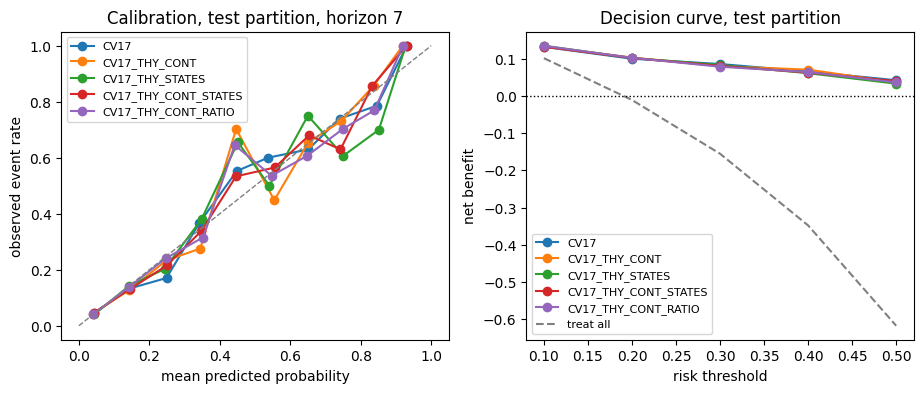

In [18]:
import matplotlib.pyplot as plt

horizon = config.HORIZONS[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for feature_set in config.TUNING_FEATURE_SETS:
    arm = arms[(horizon, feature_set, "paper")]
    frame = arm["frame"]
    points = utils.reliability_points(frame["y_true"], frame["proba_calibrated"])
    axes[0].plot(points["mean_predicted"], points["observed_rate"], marker="o",
                 label=feature_set)
    curve = decision_curves[(decision_curves["horizon"] == horizon)
                            & (decision_curves["feature_set"] == feature_set)
                            & (decision_curves["ensemble"] == "paper")]
    axes[1].plot(curve["threshold"], curve["net_benefit_model"], marker="o",
                 label=feature_set)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[0].set_xlabel("mean predicted probability")
axes[0].set_ylabel("observed event rate")
axes[0].set_title(f"Calibration, test partition, horizon {horizon}")
axes[0].legend(fontsize=8)

reference = decision_curves[(decision_curves["horizon"] == horizon)
                            & (decision_curves["feature_set"] == config.PRIMARY_BASELINE)
                            & (decision_curves["ensemble"] == "paper")]
axes[1].plot(reference["threshold"], reference["net_benefit_treat_all"],
             linestyle="--", color="grey", label="treat all")
axes[1].axhline(0.0, linestyle=":", color="black", linewidth=1)
axes[1].set_xlabel("risk threshold")
axes[1].set_ylabel("net benefit")
axes[1].set_title("Decision curve, test partition")
axes[1].legend(fontsize=8)
utils.save_fig(fig, f"calibration_and_decision_curve_h{horizon}")
plt.show()

In [19]:
utils.write_manifest(
    config.RESULTS_DIR / "frozen_configuration.json",
    stage="3_sampling_ensemble_calibration",
    adapted_ensemble={int(h): adapted[h] for h in config.HORIZONS},
    paper_ensemble=config.PAPER_ENSEMBLE,
    calibration_primary=config.CALIBRATION_PRIMARY,
    thresholds={f"h{h}_{fs}_{c}": float(arm["threshold"])
                for (h, fs, c), arm in arms.items()},
    frozen_artifacts=sorted(p.name for p in config.PRED_DIR.glob("*_test.csv")))
print("test outcomes were not used for development or selection; "
      "downstream notebooks read predictions/")

test outcomes were not used for development or selection; downstream notebooks read predictions/
